In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ==========================================================
# 2. Import Library
# ==========================================================
import os
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [3]:
# ==========================================================
# 3. Membaca Dataset
# ==========================================================
folder_path = "/content/drive/MyDrive/SKRIPSI MANTAP/data sosmed/Facebook"

embedding_df = pd.read_csv(os.path.join(folder_path, "fb_embed_lightgbm.csv"))
label_df = pd.read_csv(os.path.join(folder_path, "fb_pseudo.csv"))

print("Embedding :", embedding_df.shape)
print("Pseudo    :", label_df.shape)

Embedding : (12805, 769)
Pseudo    : (12805, 3)


In [4]:
# ==========================================================
# 4. Merge Dataset
# ==========================================================
df = pd.merge(
    embedding_df,
    label_df[["fb_clean", "label_sentimen", "confidence_score"]],
    on="fb_clean",
    how="inner"
)

print(df.head())
print(df.shape)

                                            fb_clean     emb_0     emb_1  \
0                     tuntutan dalam 7 hari kedepan:  0.349524  0.469502   
1  kalau ada pejabat yg korupsi, jangan harap lgi...  0.401149 -0.010408   
2  para pejabat publik sering pamer harta benda, ...  0.266450  0.123633   
3  drpada fasilitas umum dan pertokoan ya mending...  0.240548 -0.653231   
4             hahaha it's hilarious, rampok dirampok -0.301057 -0.650092   

      emb_2     emb_3     emb_4     emb_5     emb_6     emb_7     emb_8  ...  \
0 -0.455711  1.060343 -0.944428 -0.623701  0.804445 -0.000309 -0.053570  ...   
1 -0.856751 -0.067807 -0.651826 -0.213448  0.428385 -0.033582  0.150996  ...   
2 -0.815639  0.165540 -0.499280 -0.345886  0.423731  0.373786  0.481822  ...   
3 -0.546356 -0.253048 -0.381092 -0.447134  0.123042  0.798789  0.505045  ...   
4 -0.834931 -0.428451 -0.624564 -0.697487  0.443197  0.530899  0.069643  ...   

    emb_760   emb_761   emb_762   emb_763   emb_764   emb_765 

In [5]:
# ==========================================================
# 5. Filter Confidence Score
# ==========================================================
# Gunakan jika ingin hanya memakai pseudo label yang yakin

df = df[df["confidence_score"] >= 0.80].reset_index(drop=True)

print("Jumlah data setelah filter :", len(df))

Jumlah data setelah filter : 11001


In [6]:
# ==========================================================
# 6. Menentukan Feature dan Label
# ==========================================================
embedding_cols = [col for col in df.columns if col.startswith("emb_")]

X = df[embedding_cols].values

y = df["label_sentimen"]

print("Jumlah fitur :", len(embedding_cols))
print("Shape X :", X.shape)

Jumlah fitur : 768
Shape X : (11001, 768)


In [7]:
# ==========================================================
# 7. Label Encoding
# ==========================================================
encoder = LabelEncoder()

y = encoder.fit_transform(y)

print("Label kelas :", encoder.classes_)

Label kelas : ['negative' 'neutral' 'positive']


In [8]:
# ==========================================================
# 8. Train Test Split
# ==========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

Train : (8800, 768)
Test  : (2201, 768)


In [9]:
# ==========================================================
# 9. Training LightGBM
# ==========================================================
model = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=3,
    learning_rate=0.05,
    n_estimators=300,
    num_leaves=31,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.156475 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 195840
[LightGBM] [Info] Number of data points in the train set: 8800, number of used features: 768
[LightGBM] [Info] Start training from score -0.267582
[LightGBM] [Info] Start training from score -2.115540
[LightGBM] [Info] Start training from score -2.169764


LGBMClassifier(learning_rate=0.05, n_estimators=300, num_class=3,
               objective='multiclass', random_state=42)

In [10]:
# ==========================================================
# 10. Prediksi
# ==========================================================
y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [11]:
# ==========================================================
# 11. Evaluasi Model
# ==========================================================
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("="*50)
print("HASIL EVALUASI LIGHTGBM")
print("="*50)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

HASIL EVALUASI LIGHTGBM
Accuracy  : 0.9032
Precision : 0.9025
Recall    : 0.9032
F1 Score  : 0.8952


In [12]:
# ==========================================================
# 12. Classification Report
# ==========================================================
print(classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_
))

              precision    recall  f1-score   support

    negative       0.91      0.99      0.95      1684
     neutral       0.87      0.70      0.78       266
    positive       0.91      0.55      0.68       251

    accuracy                           0.90      2201
   macro avg       0.90      0.74      0.80      2201
weighted avg       0.90      0.90      0.90      2201



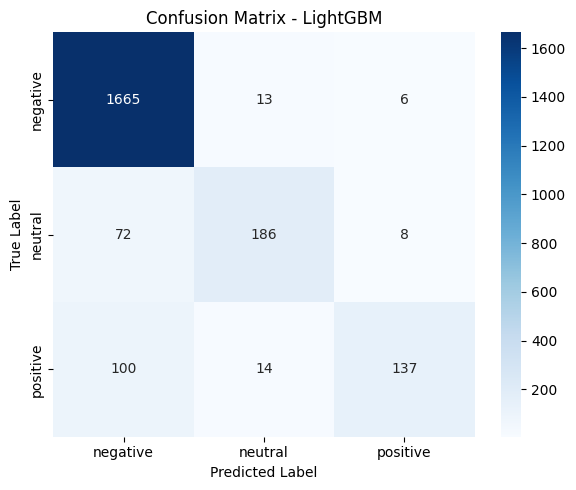

[[1665   13    6]
 [  72  186    8]
 [ 100   14  137]]


In [13]:
# ==========================================================
# 13. Confusion Matrix
# ==========================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("Confusion Matrix - LightGBM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()
print(cm)

In [14]:
# ==========================================================
# Prediksi Seluruh Dataset
# ==========================================================
df["prediksi"] = model.predict(X)

# Mengembalikan label angka menjadi label asli
df["prediksi"] = encoder.inverse_transform(df["prediksi"])

df.head()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,fb_clean,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,...,emb_761,emb_762,emb_763,emb_764,emb_765,emb_766,emb_767,label_sentimen,confidence_score,prediksi
0,tuntutan dalam 7 hari kedepan:,0.349524,0.469502,-0.455711,1.060343,-0.944428,-0.623701,0.804445,-0.000309,-0.053570,...,0.122036,-0.154803,-0.522795,-0.113418,-0.629912,-0.393764,1.385158,neutral,0.969857,neutral
1,"kalau ada pejabat yg korupsi, jangan harap lgi...",0.401149,-0.010408,-0.856751,-0.067807,-0.651826,-0.213448,0.428385,-0.033582,0.150996,...,-0.302208,-0.166959,0.257476,-0.407500,0.015769,-0.800752,0.632895,negative,0.982749,negative
2,drpada fasilitas umum dan pertokoan ya mending...,0.240548,-0.653231,-0.546356,-0.253048,-0.381092,-0.447134,0.123042,0.798789,0.505045,...,-0.609819,-0.961925,-0.004825,-0.134876,-0.588308,-0.341015,0.867119,negative,0.991846,negative
3,"hahaha it's hilarious, rampok dirampok",-0.301057,-0.650092,-0.834931,-0.428451,-0.624564,-0.697487,0.443197,0.530899,0.069643,...,-0.032997,-0.471635,-0.279732,-0.813133,-0.637595,-0.215468,0.125315,negative,0.993810,negative
4,"mungkin caranya salah, tapi tidak ada cara lai...",0.721875,0.237147,-0.775260,0.728218,-0.432285,-0.289211,0.447745,0.581810,-0.014418,...,0.234734,-0.582287,0.329358,-0.563640,0.011280,-0.093251,0.691037,negative,0.992167,negative


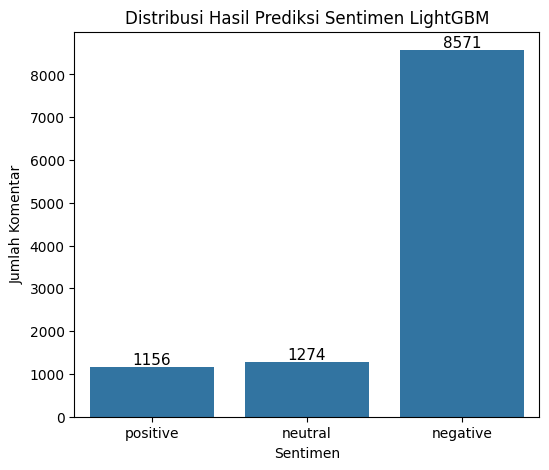

In [15]:
# ==========================================================
# Bar Chart + Jumlah
# ==========================================================
plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x="prediksi",
    order=["positive","neutral","negative"]
)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x()+p.get_width()/2,
         p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.title("Distribusi Hasil Prediksi Sentimen LightGBM")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Komentar")

plt.show()

In [16]:
df = df[df["confidence_score"] > 0.8].reset_index(drop=True)

print(f"Jumlah data setelah filter: {len(df):,}")
print(df["label_sentimen"].value_counts())

Jumlah data setelah filter: 11,001
label_sentimen
negative    8418
neutral     1327
positive    1256
Name: count, dtype: int64
